<a href="https://colab.research.google.com/github/marcehluna/VC/blob/main/Ejercicio_para_entrega_con_CNN_sin_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Preparación del Entorno y Librerías

Instalar y importar todas las librerías de Python necesarias para llevar a cabo el ejercicio. Esto incluirá herramientas para la manipulación de datos, procesamiento de imágenes, construcción y entrenamiento de modelos de Deep Learning, y visualización.


In [1]:
print('Installing required libraries...')
!pip install numpy pandas opencv-python tensorflow scikit-learn matplotlib seaborn
print('Libraries installed successfully.')

Installing required libraries...
Libraries installed successfully.


In [2]:
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print('Libraries imported successfully.')

Libraries imported successfully.


## Carga y Exploración del Dataset

Cargar el conjunto de datos de emociones. Realizar una exploración inicial para entender su estructura, el formato de los datos, el número de clases de emociones, la distribución de las muestras y la presencia de posibles desequilibrios. Se mostrarán ejemplos de datos y etiquetas para una mejor comprensión.


In [3]:
print('Downloading dataset ZIP file...')
!wget -O /content/human-face-emotions.zip "www.kaggle.com/api/v1/datasets/download/samithsachidanandan/human-face-emotions"
print('Dataset ZIP file downloaded successfully to /content/human-face-emotions.zip.')

--2026-01-28 14:51:45--  http://www.kaggle.com/api/v1/datasets/download/samithsachidanandan/human-face-emotions
Resolving www.kaggle.com (www.kaggle.com)... 35.244.233.98
Connecting to www.kaggle.com (www.kaggle.com)|35.244.233.98|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.kaggle.com/api/v1/datasets/download/samithsachidanandan/human-face-emotions [following]
--2026-01-28 14:51:45--  https://www.kaggle.com/api/v1/datasets/download/samithsachidanandan/human-face-emotions
Connecting to www.kaggle.com (www.kaggle.com)|35.244.233.98|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://storage.googleapis.com:443/kaggle-data-sets/8602141/13545313/bundle/archive.zip?X-Goog-Algorithm=GOOG4-RSA-SHA256&X-Goog-Credential=gcp-kaggle-com%40kaggle-161607.iam.gserviceaccount.com%2F20260128%2Fauto%2Fstorage%2Fgoog4_request&X-Goog-Date=20260128T145145Z&X-Goog-Expires=259200&X-Goog-SignedHeaders=host&X-Goog-Signature=06a35d

In [4]:
import os

print('Unzipping dataset file...')
# Create the target directory if it doesn't exist
output_dir = '/content/human_face_emotions'
os.makedirs(output_dir, exist_ok=True)
!unzip -q /content/human-face-emotions.zip -d {output_dir}
print(f'Dataset unzipped successfully to {output_dir}.')


Unzipping dataset file...
Dataset unzipped successfully to /content/human_face_emotions.


In [5]:
image_paths = []
emotion_labels = []

base_dir = '/content/human_face_emotions'

print(f'Collecting image paths and emotion labels from {base_dir}...')

# Check if there's an intermediate 'Data' directory, which is common for Kaggle datasets
# If it exists, set that as the new base_dir for emotion categories
initial_contents = os.listdir(base_dir)
if len(initial_contents) == 1 and initial_contents[0] == 'Data':
    base_dir = os.path.join(base_dir, 'Data')

# Iterate through each emotion subdirectory
for emotion_name in os.listdir(base_dir):
    emotion_dir = os.path.join(base_dir, emotion_name)
    if os.path.isdir(emotion_dir):
        # Iterate through images in each emotion directory
        for image_file in os.listdir(emotion_dir):
            if image_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(os.path.join(emotion_dir, image_file))
                emotion_labels.append(emotion_name)

print(f'Finished collecting {len(image_paths)} images with their labels.')


Finished collecting 59099 images with their labels.


In [6]:
df = pd.DataFrame({'path': image_paths, 'emotion': emotion_labels})

print('DataFrame created successfully. Displaying first 5 rows:')
print(df.head())

DataFrame created successfully. Displaying first 5 rows:
                                                path emotion
0     /content/human_face_emotions/Data/Sad/1834.png     Sad
1  /content/human_face_emotions/Data/Sad/27040460...     Sad
2  /content/human_face_emotions/Data/Sad/96073445...     Sad
3     /content/human_face_emotions/Data/Sad/5918.png     Sad
4      /content/human_face_emotions/Data/Sad/317.png     Sad


In [7]:
print('Number of images per emotion class:')
emotion_counts = df['emotion'].value_counts()
print(emotion_counts)

Number of images per emotion class:
emotion
Happy      18439
Sad        12553
Angry      10148
Fear        9732
Suprise     8227
Name: count, dtype: int64


Se muestra la distribución de las emociones en el dataset. Esta distribución es relevante para el entrenamiento del modelo.

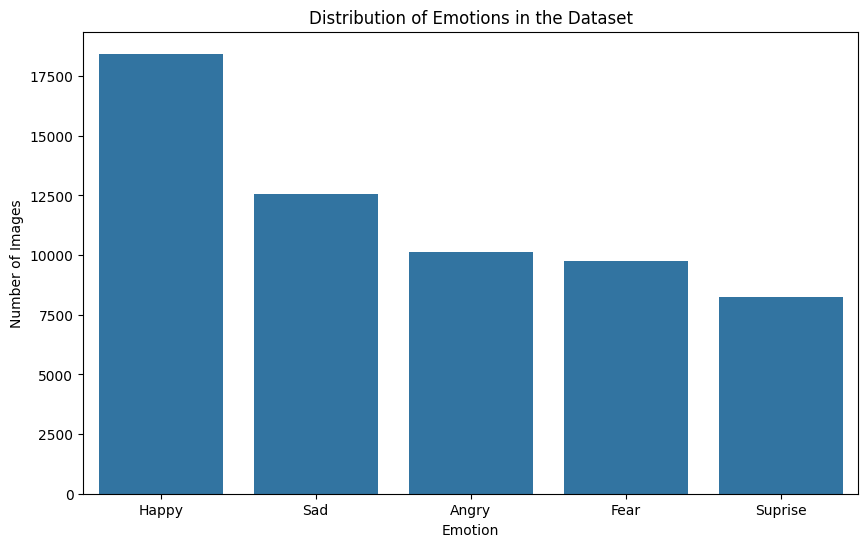

Bar plot showing emotion distribution displayed successfully.


In [8]:
plt.figure(figsize=(10, 6))
sns.countplot(x='emotion', data=df, order=df['emotion'].value_counts().index)
plt.title('Distribution of Emotions in the Dataset')
plt.xlabel('Emotion')
plt.ylabel('Number of Images')
plt.show()
print('Bar plot showing emotion distribution displayed successfully.')

## Preprocesamiento de Datos


Realizar todas las operaciones de preprocesamiento necesarias para preparar los datos para la entrada a la red neuronal convolucional (CNN).


In [9]:
TARGET_DIM = (48, 48) # Define target image dimension (width, height)
TRAIN_TEST_SPLIT_PERCENTAGE = 0.20 # Define percentage for test set

print(f"Target image dimension set to: {TARGET_DIM}")
print(f"Train-test split percentage set to: {TRAIN_TEST_SPLIT_PERCENTAGE*100}% for test set.")

# --- DNN Face Detector (Caffe model) ---
PROTOTXT_PATH_LOCAL = 'deploy.prototxt'
CAFFEMODEL_PATH_LOCAL = 'res10_300x300_ssd_iter_140000_fp16.caffemodel'

# Construct absolute paths for OpenCV
PROTOTXT_PATH_ABSOLUTE = os.path.join('/content/', PROTOTXT_PATH_LOCAL)
CAFFEMODEL_PATH_ABSOLUTE = os.path.join('/content/', CAFFEMODEL_PATH_LOCAL)

# Remove existing files to ensure fresh download
if os.path.exists(PROTOTXT_PATH_ABSOLUTE):
    os.remove(PROTOTXT_PATH_ABSOLUTE)
    print(f'Removed existing {PROTOTXT_PATH_LOCAL}.')
if os.path.exists(CAFFEMODEL_PATH_ABSOLUTE):
    os.remove(CAFFEMODEL_PATH_ABSOLUTE)
    print(f'Removed existing {CAFFEMODEL_PATH_LOCAL}.')

# Download prototxt file
print(f'Downloading {PROTOTXT_PATH_LOCAL}...')
!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt -O {PROTOTXT_PATH_ABSOLUTE}
print(f'{PROTOTXT_PATH_LOCAL} downloaded.')

# Check if prototxt file exists and is not empty
if not os.path.exists(PROTOTXT_PATH_ABSOLUTE) or os.path.getsize(PROTOTXT_PATH_ABSOLUTE) == 0:
    print(f"Error: {PROTOTXT_PATH_LOCAL} not found or is empty after download. Please check the URL and network connection.")
    net = None # Set net to None to prevent further errors if file is missing/empty
else:
    # Download caffemodel file
    print(f'Downloading {CAFFEMODEL_PATH_LOCAL}...')
    # Updated URL for caffemodel
    !wget https://huggingface.co/Durraiya/res10_300x300_ssd_iter_140000_fp16.caffemodel/resolve/main/res10_300x300_ssd_iter_140000_fp16.caffemodel -O {CAFFEMODEL_PATH_ABSOLUTE}
    print(f'{CAFFEMODEL_PATH_LOCAL} downloaded.')

    # Check if caffemodel file exists and is not empty
    if not os.path.exists(CAFFEMODEL_PATH_ABSOLUTE) or os.path.getsize(CAFFEMODEL_PATH_ABSOLUTE) == 0:
        print(f"Error: {CAFFEMODEL_PATH_LOCAL} not found or is empty after download. Please check the URL and network connection.")
        net = None # Set net to None to prevent further errors if file is missing/empty
    else:
        # Load the DNN face detector using absolute paths
        net = cv2.dnn.readNetFromCaffe(PROTOTXT_PATH_ABSOLUTE, CAFFEMODEL_PATH_ABSOLUTE)

if net is None or net.empty():
    print("Error: Could not load DNN face detector model. Re-check file integrity, paths, and content.")
else:
    print("DNN face detector model loaded successfully.")

Target image dimension set to: (48, 48)
Train-test split percentage set to: 20.0% for test set.
--2026-01-28 14:53:08--  https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28104 (27K) [text/plain]
Saving to: ‘/content/deploy.prototxt’

/content/deploy.pro 100%[===================>]  27.45K  --.-KB/s    in 0.002s  

2026-01-28 14:53:08 (15.4 MB/s) - ‘/content/deploy.prototxt’ saved [28104/28104]

deploy.prototxt downloaded.
--2026-01-28 14:53:08--  https://huggingface.co/Durraiya/res10_300x300_ssd_iter_140000_fp16.caffemodel/resolve/main/res10_300x300_ssd_iter_140000_fp16.caffemodel
Resolving huggingface.co (huggingface.co)... 3.163.189.114, 3.163.189.37, 3.163.189.7

In [10]:
processed_images = []
processed_labels = []

# Map emotion names to numerical labels
# This assumes emotion_counts has the emotion names as index
emotion_to_int = {emotion: i for i, emotion in enumerate(df['emotion'].unique())}
int_to_emotion = {i: emotion for emotion, i in emotion_to_int.items()}
num_classes = len(emotion_to_int)

print(f"Mapping emotions to integers: {emotion_to_int}")

def process_image(image_path, emotion_label):
    img = cv2.imread(image_path)
    if img is None:
        return None

    (h, w) = img.shape[:2]
    blob = cv2.dnn.blobFromImage(cv2.resize(img, (300, 300)), 1.0, (300, 300), (104.0, 177.0, 123.0))

    net.setInput(blob)
    detections = net.forward()

    faces = []
    for i in range(0, detections.shape[2]):
        confidence = detections[0, 0, i, 2]

        if confidence > 0.5: # Filter weak detections
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (startX, startY, endX, endY) = box.astype("int")
            faces.append((startX, startY, endX - startX, endY - startY))

    if len(faces) == 0:
        return None # No face detected, skip this image

    # Select the largest face if multiple are detected
    (x, y, w, h) = max(faces, key=lambda rect: rect[2] * rect[3])

    # Crop the face region from grayscale image
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    face_roi = gray[y:y+h, x:x+w]

    # Resize the cropped face to the target dimension
    resized_face = cv2.resize(face_roi, TARGET_DIM)

    processed_images.append(resized_face)
    processed_labels.append(emotion_to_int[emotion_label])
    return 1 # Indicate successful processing

print(f'Processing {len(df)} images...')
# Apply the processing function to each row of the DataFrame
# Using tqdm for a progress bar
from tqdm import tqdm
tqdm.pandas()
df.progress_apply(lambda row: process_image(row['path'], row['emotion']), axis=1)

print(f'Finished processing images. Collected {len(processed_images)} valid faces.')

Mapping emotions to integers: {'Sad': 0, 'Happy': 1, 'Suprise': 2, 'Angry': 3, 'Fear': 4}
Processing 59099 images...


100%|██████████| 59099/59099 [56:15<00:00, 17.51it/s]

Finished processing images. Collected 58532 valid faces.


In [11]:
X = np.array(processed_images)
y = np.array(processed_labels)

print(f"Original shape of X: {X.shape}")
print(f"Original shape of y: {y.shape}")

# Normalize pixel values to 0-1
X = X / 255.0
print(f"Shape of X after normalization: {X.shape}")

# Reshape images to include channel dimension (height, width, 1)
X = X.reshape(-1, TARGET_DIM[0], TARGET_DIM[1], 1)
print(f"Shape of X after reshaping: {X.shape}")

# One-hot encode labels
y = tf.keras.utils.to_categorical(y, num_classes=num_classes)
print(f"Shape of y after one-hot encoding: {y.shape}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TRAIN_TEST_SPLIT_PERCENTAGE, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

print('Data preprocessing completed and split into training and testing sets.')

Original shape of X: (58532, 48, 48)
Original shape of y: (58532,)
Shape of X after normalization: (58532, 48, 48)
Shape of X after reshaping: (58532, 48, 48, 1)
Shape of y after one-hot encoding: (58532, 5)
X_train shape: (46825, 48, 48, 1)
y_train shape: (46825, 5)
X_test shape: (11707, 48, 48, 1)
y_test shape: (11707, 5)
Data preprocessing completed and split into training and testing sets.


## Definición del Modelo CNN

Diseñar y construir la arquitectura de la red neuronal convolucional (CNN). Se definirá el número de capas convolucionales, capas de pooling, capas densas, funciones de activación y la capa de salida, basándose en las recomendaciones del ejercicio o en arquitecturas comunes para reconocimiento de emociones. Se mostrará un resumen del modelo.


In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

print('Defining CNN model architecture...')

model = Sequential([
    Conv2D(32, (3, 3), padding='same', input_shape=(TARGET_DIM[0], TARGET_DIM[1], 1), activation='relu'),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

print('CNN model architecture defined successfully. Model Summary:')
model.summary()

Defining CNN model architecture...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN model architecture defined successfully. Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 46, 46, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 23, 23, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 21, 21, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,344,869 (12.76 MB)

 Trainable params: 3,344,869 (12.76 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
print('Compiling the CNN model...')

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('CNN model compiled successfully with Adam optimizer, categorical crossentropy loss, and accuracy metric.')

Compiling the CNN model...
CNN model compiled successfully with Adam optimizer, categorical crossentropy loss, and accuracy metric.


## Entrenamiento del Modelo (con early stopping - Patience 5)

Entrenar el modelo CNN utilizando el conjunto de entrenamiento y validándolo con el conjunto de prueba. Los valores de épocas, batch size y paciencia fueron ajustados en diferentes corridas para encontrar un rendimiento aceptable.


In [14]:
from tensorflow.keras.callbacks import EarlyStopping

EPOCHS = 40
BATCH_SIZE = 64
PATIENCE = 5 # Number of epochs with no improvement after which training will be stopped

print(f"Starting model training with {EPOCHS} epochs, batch size of {BATCH_SIZE}, and Early Stopping patience of {PATIENCE}...")

early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=PATIENCE,   # Number of epochs to wait before stopping
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping] # Add the Early Stopping callback
)

print('Model training completed. Training history stored in `history` variable.')

Starting model training with 40 epochs, batch size of 64, and Early Stopping patience of 5...
Epoch 1/40
732/732 ━━━━━━━━━━━━━━━━━━━━ 453s 614ms/step - accuracy: 0.3871 - loss: 1.4378 - val_accuracy: 0.5765 - val_loss: 1.0652
Epoch 2/40
732/732 ━━━━━━━━━━━━━━━━━━━━ 524s 646ms/step - accuracy: 0.5746 - loss: 1.0634 - val_accuracy: 0.6233 - val_loss: 0.9374
Epoch 3/40
732/732 ━━━━━━━━━━━━━━━━━━━━ 470s 641ms/step - accuracy: 0.6297 - loss: 0.9403 - val_accuracy: 0.6724 - val_loss: 0.8285
Epoch 4/40
732/732 ━━━━━━━━━━━━━━━━━━━━ 499s 638ms/step - accuracy: 0.6754 - loss: 0.8252 - val_accuracy: 0.7022 - val_loss: 0.7824
Epoch 5/40
732/732 ━━━━━━━━━━━━━━━━━━━━ 508s 645ms/step - accuracy: 0.7150 - loss: 0.7412 - val_accuracy: 0.7432 - val_loss: 0.6928
Epoch 6/40
732/732 ━━━━━━━━━━━━━━━━━━━━ 472s 645ms/step - accuracy: 0.7391 - loss: 0.6755 - val_accuracy: 0.7661 - val_loss: 0.6402
Epoch 7/40
732/732 ━━━━━━━━━━━━━━━━━━━━ 483s 619ms/step - accuracy: 0.7660 - loss: 0.6007 - val_accuracy: 0.7857 -

### Visualización del Historial de Entrenamiento

Vamos a graficar la precisión (accuracy) y la pérdida (loss) tanto para el conjunto de entrenamiento como para el de validación a lo largo de las épocas. Esto nos permitirá observar el rendimiento del modelo y detectar posibles problemas como el sobreajuste (overfitting) o subajuste (underfitting).

Generating plots for training history...


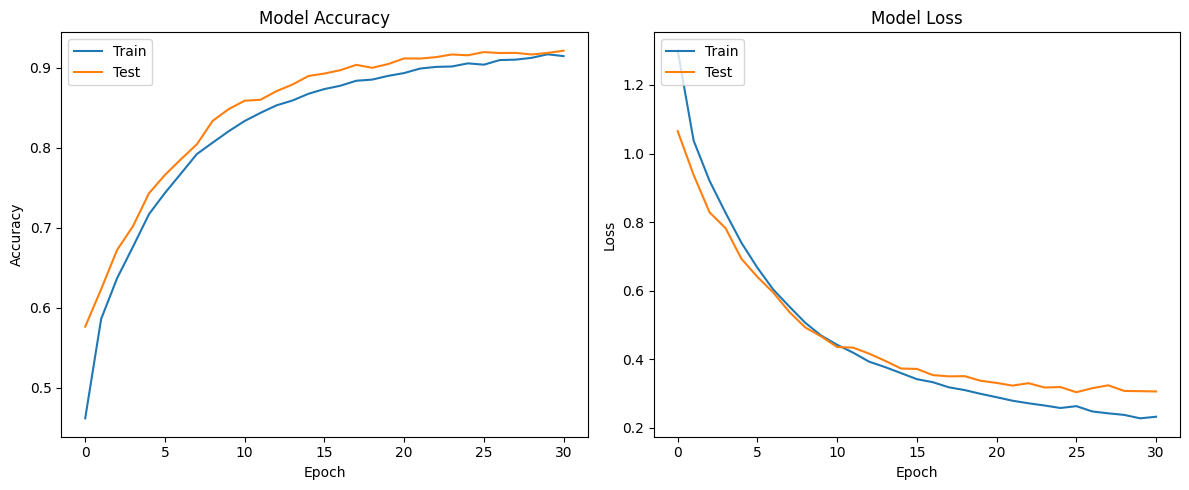

Training history plots generated successfully.


In [15]:
print('Generating plots for training history...')

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.tight_layout()
plt.show()
print('Training history plots generated successfully.')

## Cargar y Predecir Emoción de Imagen

### Subtask:
Permitir al usuario cargar una imagen, preprocesarla detectando y recortando un rostro, y luego utilizar el modelo entrenado para predecir y mostrar la emoción detectada con su nivel de confianza.


Please upload an image for emotion prediction.


Saving cara7.jpg to cara7.jpg
Uploaded file: cara7.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Detected Emotion: Sad with 61.11% confidence.


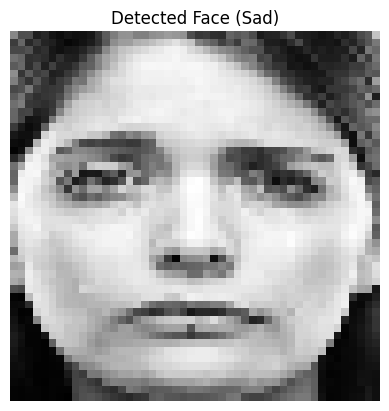

Cleaned up uploaded file: cara7.jpg


In [22]:
from google.colab import files

print('Please upload an image for emotion prediction.')

uploaded = files.upload()

if not uploaded:
    print('No image uploaded. Please try again.')
else:
    for filename in uploaded.keys():
        print(f'Uploaded file: {filename}')
        user_image_path = filename

        # Read the uploaded image
        img = cv2.imread(user_image_path)

        if img is None:
            print(f"Error: Could not load image {user_image_path}. Please ensure it's a valid image file.")
        else:
            (h, w) = img.shape[:2]
            blob = cv2.dnn.blobFromImage(cv2.resize(img, (300, 300)), 1.0, (300, 300), (104.0, 177.0, 123.0))

            net.setInput(blob)
            detections = net.forward()

            faces = []
            for i in range(0, detections.shape[2]):
                confidence = detections[0, 0, i, 2]

                if confidence > 0.5: # Filter weak detections
                    box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
                    (startX, startY, endX, endY) = box.astype("int")
                    faces.append((startX, startY, endX - startX, endY - startY))

            if len(faces) == 0:
                print('No face detected in the uploaded image. Please try another image.')
            else:
                # Select the largest face if multiple are detected
                (x, y, w, h) = max(faces, key=lambda rect: rect[2] * rect[3])

                # Crop the face region
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                face_roi = gray[y:y+h, x:x+w]

                # Resize the cropped face to the target dimension
                resized_face = cv2.resize(face_roi, TARGET_DIM)

                # Normalize pixel values
                normalized_face = resized_face / 255.0

                # Reshape for model input (add batch and channel dimensions)
                model_input_face = normalized_face.reshape(1, TARGET_DIM[0], TARGET_DIM[1], 1)

                # Predict emotion
                predictions = model.predict(model_input_face)
                predicted_emotion_index = np.argmax(predictions[0])
                predicted_emotion_label = int_to_emotion[predicted_emotion_index]
                confidence = predictions[0][predicted_emotion_index] * 100

                print(f'Detected Emotion: {predicted_emotion_label} with {confidence:.2f}% confidence.')

                # Display the preprocessed face image
                plt.imshow(resized_face, cmap='gray')
                plt.title(f'Detected Face ({predicted_emotion_label})')
                plt.axis('off')
                plt.show()

                # Clean up the uploaded file
                os.remove(user_image_path)
                print(f'Cleaned up uploaded file: {user_image_path}')